In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import numpy as np

print("Tensorflow version: " + tf.__version__)
print("Keras version: " + tf.keras.__version__)

Tensorflow version: 2.20.0
Keras version: 3.13.2


In [25]:
########################################################################################################################
# PARAMETERS
########################################################################################################################

max_features = 10000  # number of words to consider as features
max_len = 500  # cut texts after this number of words (among top max_features most common words)
embedding_dim = 50
batch_size = 2048
init_lr = 1e-3

In [26]:
########################################################################################################################
# LOADING DATA
########################################################################################################################

print('Loading data...')
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=max_features)
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

print('Pad sequences (samples x time)')
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('x_test shape:', y_test.shape)
print('x_train sample:', x_train[0])
print('y_train samples:', y_train[:10])

Loading data...
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
x_train shape: (25000, 500)
y_train shape: (25000,)
x_test shape: (25000, 500)
x_test shape: (25000,)
x_train sample: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0 

In [27]:
########################################################################################################################
# BUILDING MODEL
########################################################################################################################

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input((max_len,)))
model.add(tf.keras.layers.Embedding(max_features, embedding_dim))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.SimpleRNN(64))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=init_lr)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.binary_crossentropy,
              metrics=[tf.keras.metrics.binary_accuracy])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 500, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507,425 (1.94 MB)

 Trainable params: 507,425 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
########################################################################################################################
# TRAINING MODEL
########################################################################################################################

path = os.path.join(os.getcwd(), 'trained_model.keras')
save_model = tf.keras.callbacks.ModelCheckpoint(path, monitor='val_binary_accuracy', mode='max',
                                                verbose=1, save_best_only=True)

csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(os.getcwd(), 'training.csv'))

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', mode='max',
                                                  patience=30, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_binary_accuracy', mode='max',
                                                 factor=0.1, patience=10, verbose=1)

hist = model.fit(x_train, y_train,
                 epochs=1000,
                 batch_size=batch_size,
                 validation_data=(x_test, y_test),
                 shuffle=True,
                 callbacks=[save_model,
                            csv_logger,
                            early_stopping,
                            reduce_lr],
                 verbose=2)

model.save(path, include_optimizer=False)

Epoch 1/1000

Epoch 1: val_binary_accuracy improved from None to 0.50204, saving model to /content/trained_model.keras

Epoch 1: finished saving model to /content/trained_model.keras
13/13 - 9s - 659ms/step - binary_accuracy: 0.5182 - loss: 0.7064 - val_binary_accuracy: 0.5020 - val_loss: 0.7011 - learning_rate: 0.0010
Epoch 2/1000

Epoch 2: val_binary_accuracy improved from 0.50204 to 0.58508, saving model to /content/trained_model.keras

Epoch 2: finished saving model to /content/trained_model.keras
13/13 - 2s - 127ms/step - binary_accuracy: 0.5601 - loss: 0.6814 - val_binary_accuracy: 0.5851 - val_loss: 0.6781 - learning_rate: 0.0010
Epoch 3/1000

Epoch 3: val_binary_accuracy improved from 0.58508 to 0.69988, saving model to /content/trained_model.keras

Epoch 3: finished saving model to /content/trained_model.keras
13/13 - 2s - 132ms/step - binary_accuracy: 0.6392 - loss: 0.6452 - val_binary_accuracy: 0.6999 - val_loss: 0.5919 - learning_rate: 0.0010
Epoch 4/1000

Epoch 4: val_bina

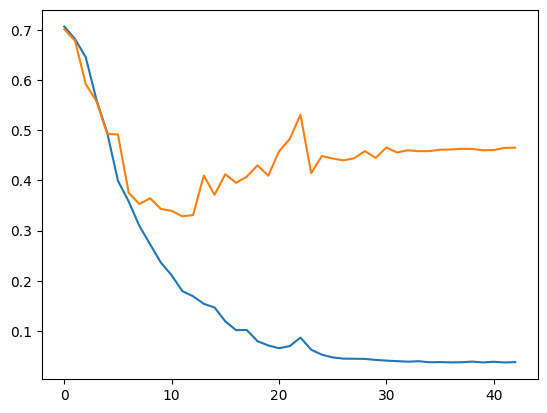

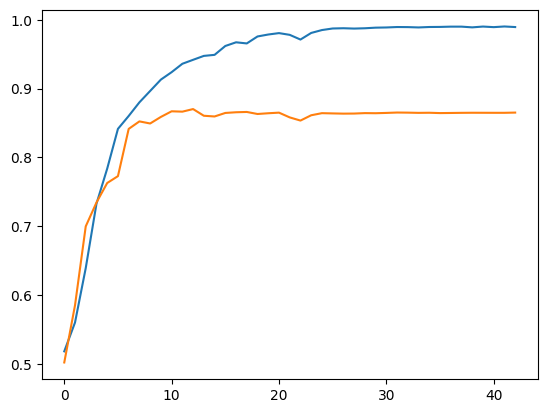

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - binary_accuracy: 0.8704 - loss: 0.3309
[0.33089762926101685, 0.8703600168228149]


In [29]:
########################################################################################################################
# EVALUATE
########################################################################################################################

plt.clf()
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.show()

plt.clf()
plt.plot(hist.history['binary_accuracy'])
plt.plot(hist.history['val_binary_accuracy'])
plt.show()

eval = model.evaluate(x_test, y_test)
print(eval)